In [1]:
import os # For navigating through folders
import numpy as np  #For math and array calculations
import matplotlib.pyplot as plt  # For drawing the EDA histogram
from PIL import Image, ImageEnhance # For applying augmentations

In [2]:
base_dir = r'C:\Users\vinuga janandith\Desktop\AIML project\data'

# 1. Analyze the current class balance
class_counts = {}
print("Analyzing class balance to determine augmentation strategy...")

# Loop through to count images per class
for root, dirs, files in os.walk(base_dir):
    if not dirs:
        class_name = os.path.basename(root)
        valid_images = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if valid_images:
            class_counts[class_name] = len(valid_images)

# 2. Calculate how many new images need to be generated
# We set our target to the class with the most images
target_count = max(class_counts.values())
augmentation_needs = {cls: target_count - count for cls, count in class_counts.items()}

print("-" * 40)
print(f"Target size for a balanced dataset: {target_count} images per class")
for cls, needed in augmentation_needs.items():
    if needed > 0:
        print(f" - {cls} needs {needed} augmented images.")
print("-" * 40)

Analyzing class balance to determine augmentation strategy...
----------------------------------------
Target size for a balanced dataset: 3348 images per class
 - Littering Garbage on Public Places Issues needs 1929 augmented images.
 - Vandalism Issues needs 1220 augmented images.
 - Broken Road Sign Issues needs 1555 augmented images.
 - Damaged Road issues needs 2671 augmented images.
 - Illegal Parking Issues needs 3244 augmented images.
 - Mixed Issues needs 3157 augmented images.
----------------------------------------


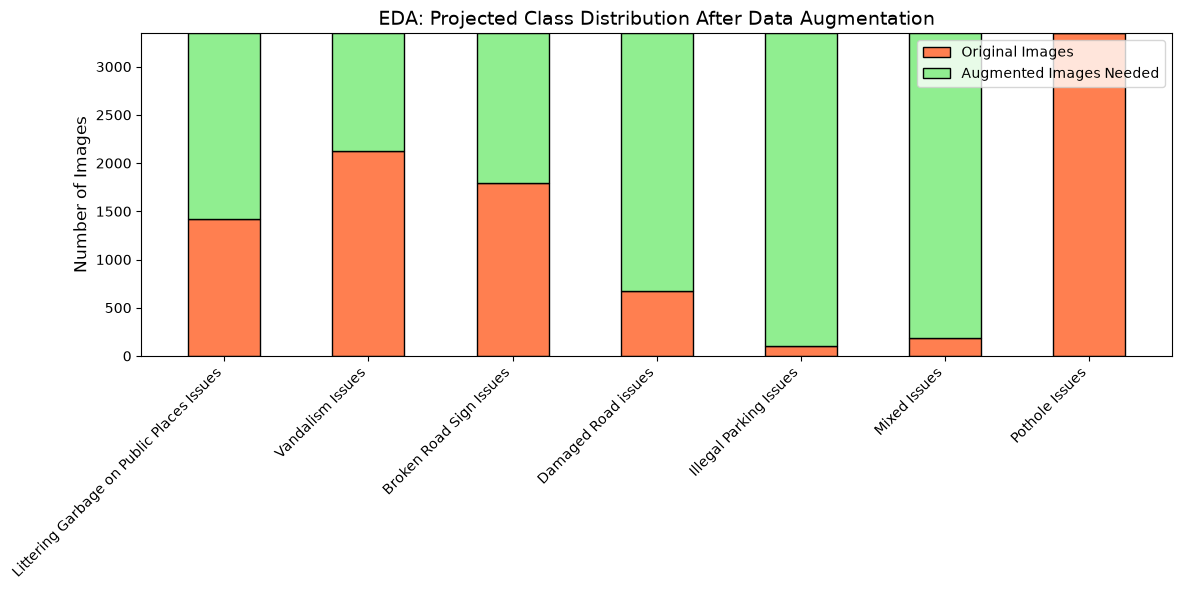

In [3]:
# EXPLORATORY DATA ANALYSIS (EDA)
# Plot: Projected Class Balance After Augmentation
plt.figure(figsize=(12, 6))
classes = list(class_counts.keys())
original_counts = list(class_counts.values())
needed_counts = [augmentation_needs[c] for c in classes]

x = np.arange(len(classes))
width = 0.5

# Stack the bars to show original + new augmented images
plt.bar(x, original_counts, width, label='Original Images', color='coral', edgecolor='black')
plt.bar(x, needed_counts, width, bottom=original_counts, label='Augmented Images Needed', color='lightgreen', edgecolor='black')

plt.title('EDA: Projected Class Distribution After Data Augmentation', fontsize=14)
plt.xticks(x, classes, rotation=45, ha='right')
plt.ylabel('Number of Images', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


Generating previews of augmentation techniques on a sample image...


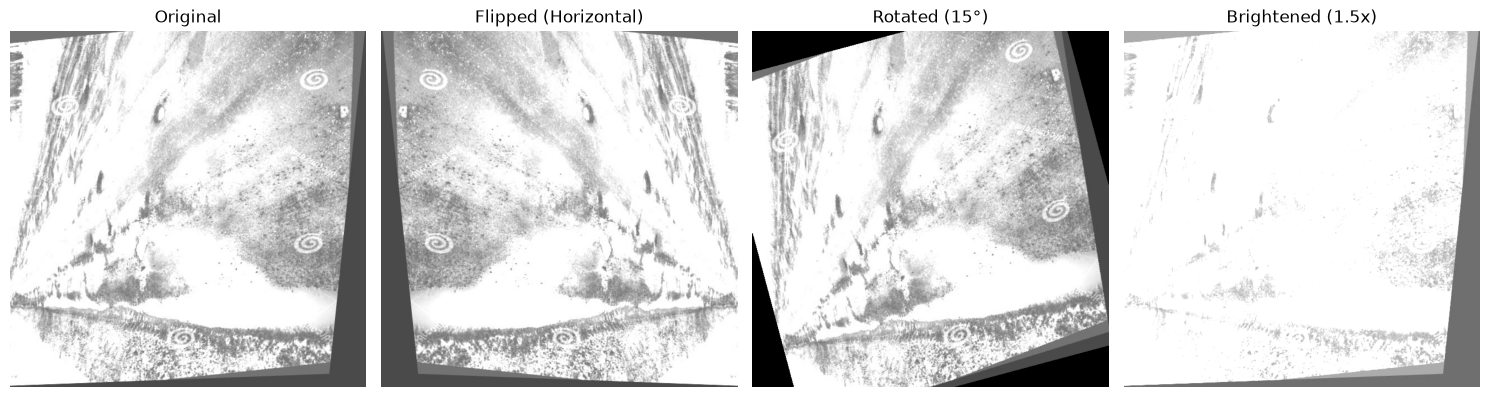

In [5]:
# AUGMENTATION DEMONSTRATION
print("\nGenerating previews of augmentation techniques on a sample image...")

# Grab one sample image to demonstrate the techniques
sample_folder = os.path.join(base_dir, 'Road Issues', 'Pothole Issues')
sample_image_path = os.path.join(sample_folder, os.listdir(sample_folder)[0])

original_img = Image.open(sample_image_path)

# Apply three different augmentation techniques
flipped_img = original_img.transpose(Image.FLIP_LEFT_RIGHT)
rotated_img = original_img.rotate(15) # Rotate by 15 degrees
bright_img = ImageEnhance.Brightness(original_img).enhance(1.5) # Increase brightness by 50%

# Plot the visual preview
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(original_img); axes[0].set_title("Original")
axes[1].imshow(flipped_img); axes[1].set_title("Flipped (Horizontal)")
axes[2].imshow(rotated_img); axes[2].set_title("Rotated (15°)")
axes[3].imshow(bright_img); axes[3].set_title("Brightened (1.5x)")

for ax in axes:
    ax.axis('off')
    
plt.tight_layout()
plt.show()